# nn. Conv2d는 사실 convolution을 하지 않는다.

박연수

In [ ]:
import torch
import torch.nn as nn

## tensor와 parameter의 차이

파라미터는 텐서지만, 텐서는 파라미터가 아니다.

In [ ]:
rnd = torch.randn(5, 5)
t = torch.tensor(rnd)
t

/tmp/ipykernel_723/1694594144.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(rnd)


tensor([[-0.7679,  0.3281,  0.8054,  1.1955, -0.6240],
        [ 0.5000, -0.1930, -0.0020, -1.0173, -0.0083],
        [-0.7387,  0.9879,  0.8556,  0.8847,  0.2356],
        [ 0.4543,  1.8703,  1.0567,  0.2428,  1.7751],
        [ 0.5252,  0.1668, -0.9017,  0.5592, -0.6604]])

In [ ]:
param = nn.Parameter(rnd)
param

Parameter containing:
tensor([[-0.7679,  0.3281,  0.8054,  1.1955, -0.6240],
        [ 0.5000, -0.1930, -0.0020, -1.0173, -0.0083],
        [-0.7387,  0.9879,  0.8556,  0.8847,  0.2356],
        [ 0.4543,  1.8703,  1.0567,  0.2428,  1.7751],
        [ 0.5252,  0.1668, -0.9017,  0.5592, -0.6604]], requires_grad=True)

In [ ]:
print(t.requires_grad)
print(param.requires_grad)

False
True


In [ ]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = param
        self.t = t

model = Model()
list(model.parameters())

[Parameter containing:
 tensor([[-0.7679,  0.3281,  0.8054,  1.1955, -0.6240],
         [ 0.5000, -0.1930, -0.0020, -1.0173, -0.0083],
         [-0.7387,  0.9879,  0.8556,  0.8847,  0.2356],
         [ 0.4543,  1.8703,  1.0567,  0.2428,  1.7751],
         [ 0.5252,  0.1668, -0.9017,  0.5592, -0.6604]], requires_grad=True)]

## Linear와 Conv2d

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 128, (3, 3))
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = Model()
print(model)
print(type(model.conv.weight), model.conv.weight.shape)
print(type(model.conv.bias), model.conv.bias.shape)

print(type(model.fc.weight), model.fc.weight.shape)
print(type(model.fc.bias), model.fc.bias.shape)

Model(
  (conv): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
<class 'torch.nn.parameter.Parameter'> torch.Size([128, 3, 3, 3])
<class 'torch.nn.parameter.Parameter'> torch.Size([128])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 128])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])


## 왜 커널을 필터라고 부를까?
1. 신호처리의 관점 필터링의 원리
2. convolution, cross-correlation의 차이
3. 그럼 CNN은 무엇을 학습할까?

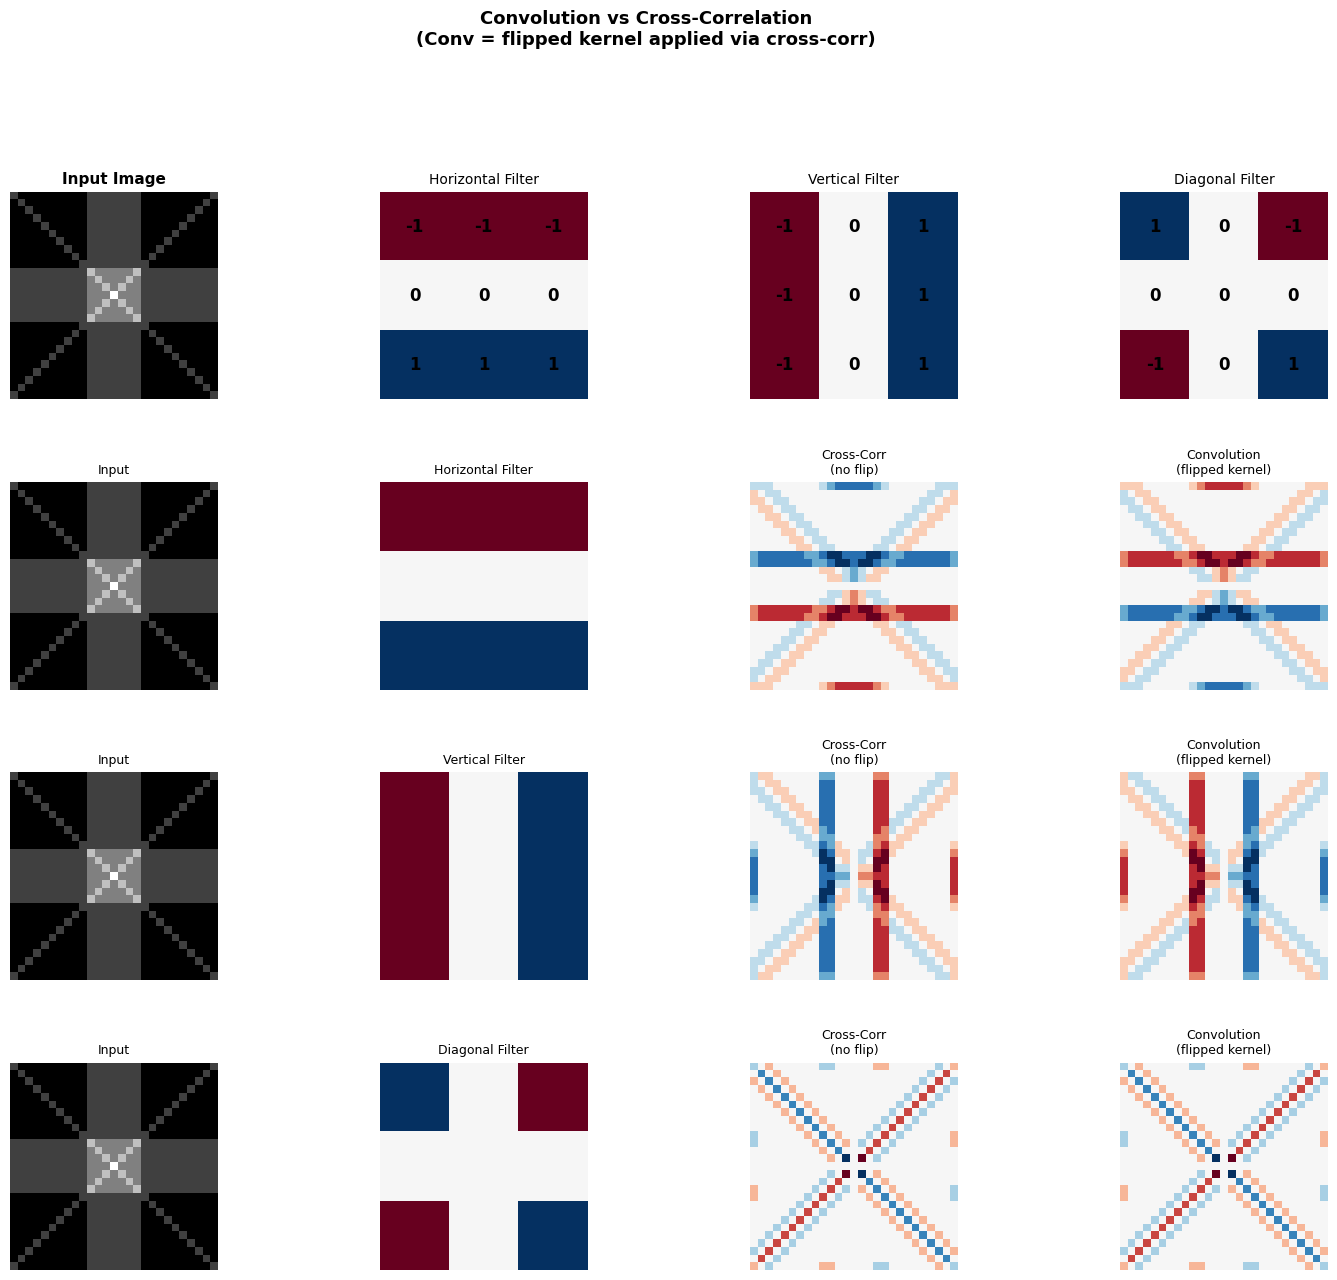

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

horiz_filter = torch.tensor([
    [-1., -1., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  1.,  1.]
])

vert_filter = torch.tensor([
    [-1.,  0.,  1.],
    [-1.,  0.,  1.],
    [-1.,  0.,  1.]
])

diag_filter = torch.tensor([
    [ 1.,  0., -1.],
    [ 0.,  0.,  0.],
    [-1.,  0.,  1.]
])

img = torch.zeros(27, 27)
img[10:17, :] = 1.0
img[:, 10:17] += 1.0
for i in range(27):
    img[i, i] += 1.0
    if i < 27:
        img[i, 26 - i] += 1.0

filters = {
    'Horizontal': horiz_filter,
    'Vertical': vert_filter,
    'Diagonal': diag_filter
}

def cross_corr(img, kernel):
    x = img.unsqueeze(0).unsqueeze(0)
    k = kernel.unsqueeze(0).unsqueeze(0)
    return F.conv2d(x, k, padding=1).squeeze()

def conv2d(img, kernel):
    x = img.unsqueeze(0).unsqueeze(0)
    k = torch.flip(kernel, [0, 1]).unsqueeze(0).unsqueeze(0)
    return F.conv2d(x, k, padding=1).squeeze()

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)

ax = fig.add_subplot(gs[0, 0])
ax.imshow(img, cmap='gray')
ax.set_title('Input Image', fontsize=11, fontweight='bold')
ax.axis('off')

filter_names = list(filters.keys())
for col, (fname, filt) in enumerate(filters.items()):
    ax = fig.add_subplot(gs[0, col + 1])
    ax.imshow(filt, cmap='RdBu', vmin=-1, vmax=1)
    ax.set_title(f'{fname} Filter', fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{filt[i,j]:.0f}', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.axis('off')

for row, (fname, filt) in enumerate(filters.items()):
    cc_result = cross_corr(img, filt)
    conv_result = conv2d(img, filt)

    ax1 = fig.add_subplot(gs[row + 1, 0])
    ax1.imshow(img, cmap='gray')
    ax1.set_title(f'Input', fontsize=9)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[row + 1, 1])
    ax2.imshow(filt, cmap='RdBu', vmin=-1, vmax=1)
    ax2.set_title(f'{fname} Filter', fontsize=9)
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[row + 1, 2])
    ax3.imshow(cc_result, cmap='RdBu')
    ax3.set_title(f'Cross-Corr\n(no flip)', fontsize=9)
    ax3.axis('off')

    ax4 = fig.add_subplot(gs[row + 1, 3])
    ax4.imshow(conv_result, cmap='RdBu')
    ax4.set_title(f'Convolution\n(flipped kernel)', fontsize=9)
    ax4.axis('off')

    for ax, label in [(ax1,'Input'), (ax3,'Cross-Corr'), (ax4,'Conv')]:
        ax.set_ylabel(fname, fontsize=9, rotation=0, labelpad=40, va='center')
        break
    ax1.set_ylabel(fname, fontsize=10, fontweight='bold', rotation=90)

plt.suptitle('Convolution vs Cross-Correlation\n(Conv = flipped kernel applied via cross-corr)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('conv_vs_corr.png', dpi=150, bbox_inches='tight')
plt.show()

## POV: ViT가 가변 입력을 받을 수 있는 이유
- conv2d는 커널 사이즈 이상의 어떤 크기의 입력도 받을 수 있음.
- 근데 CNN은 ...

In [ ]:
# 가변 입력의 극단적 예시
x1 = torch.randn(1, 3, 4, 4)
x2 = torch.randn(1, 3, 256, 256)

conv = nn.Conv2d(3, 4, (3, 3), padding=1)
fc = nn.Linear(1*4*4*4, 10)

out1 = conv(x1)
out2 = conv(x2)

# 서로 다른 사이즈의 출력
print(out1.shape, out2.shape, conv.weight.shape)

out1_f = out1.flatten(1)
out2_f = out2.flatten(1)

print(out1_f.shape, out2_f.shape, out1_f.shape == out2_f.shape )

torch.Size([1, 4, 4, 4]) torch.Size([1, 4, 256, 256]) torch.Size([4, 3, 3, 3])
torch.Size([1, 64]) torch.Size([1, 262144]) False


In [ ]:
print(fc(out1_f).shape)
print(fc(out2_f).shape)

torch.Size([1, 10])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x262144 and 64x10)

In [ ]:
pool = nn.AdaptiveAvgPool2d((4, 4))  # 어떤 입력이든 (B, C, 4, 4)로 만듦
out1_f = pool(out1).flatten(1)    # (4, 16)
out2_f = pool(out2).flatten(1)    # (4, 16) -- 같은 크기

print(out1_f.shape, out2_f.shape)

print(fc(out1_f).shape)
print(fc(out2_f).shape)

torch.Size([1, 64]) torch.Size([1, 64])
torch.Size([1, 10])
torch.Size([1, 10])
